In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells

### Diseño del bloque S1

In [2]:
@gf.cell
def ARTS1(gap=0.6, lgthIn=41.82, lgthA=22.63, lgthB=23.63, lgthOut=12.01, L1 = 23.250, L2 = 9.217, Lpi = 0.326):

    """
    Cascaded MZI 3-stage 

    Parameters
    ----------
    gap : float
        Gap of directional couplers (um)
    lgthIn : float
        Length of input coupler
    lgthA : float
        Length of first stage coupler
    lgthB : float
        Length of second stage coupler
    lgthOut : float
        Length of output coupler

    Returns
    -------
    Component
        GDS component of cascaded MZI
    """

    CMZIS1 = gf.Component()

    xs = gf.cross_section.strip(width=0.5, layer = 'WG')

    coup = gf.components.coupler(gap=0.6, length=10, cross_section=xs)
    bend = gf.components.bend_euler(cross_section=xs)
    straight = gf.components.straight(length=25, cross_section=xs)

    # Directional coupler
    InDC = CMZIS1.add_ref(gf.components.coupler(gap=gap, length=lgthIn, cross_section=xs))
    acoup = CMZIS1.add_ref(gf.components.coupler(gap=gap, length=lgthA, cross_section=xs))
    bcoup = CMZIS1.add_ref(gf.components.coupler(gap=gap, length=lgthB, cross_section=xs))
    OutDC = CMZIS1.add_ref(gf.components.coupler(gap=gap, length=lgthOut, cross_section=xs))
    #---------------------
    # MZI Aap
    #---------------------
    # Bends uper arm superior
    ab1   = CMZIS1 << bend
    ab2   = CMZIS1 << bend
    ab3   = CMZIS1 << bend
    ab4   = CMZIS1 << bend

    # Bends lower arm inferior
    ab5   = CMZIS1 << bend
    ab6   = CMZIS1 << bend
    ab7   = CMZIS1 << bend
    ab8   = CMZIS1 << bend

    # Vertical connections
    asx1   = CMZIS1.add_ref(gf.components.straight(length=1, cross_section=xs))
    asx2   = CMZIS1.add_ref(gf.components.straight(length=1, cross_section=xs))

    # Horizontal connections
    # ---- Brazo superior
    asy1   = CMZIS1.add_ref(gf.components.straight(length=L1/2, cross_section=xs))
    asy2   = CMZIS1.add_ref(gf.components.straight(length=L1/2, cross_section=xs))
    # ---- Brazo inferior
    asy3   = CMZIS1.add_ref(gf.components.straight(length=L2/2, cross_section=xs))
    asy4   = CMZIS1.add_ref(gf.components.straight(length=L2/2, cross_section=xs))  

    #---------------------
    # MZI B
    #---------------------
    # Bends uper arm superior
    bb1   = CMZIS1 << bend
    bb2   = CMZIS1 << bend
    bb3   = CMZIS1 << bend
    bb4   = CMZIS1 << bend

    # Bends lower arm inferior
    bb5   = CMZIS1 << bend
    bb6   = CMZIS1 << bend
    bb7   = CMZIS1 << bend
    bb8   = CMZIS1 << bend

    # Vertical connections
    bsx1   = CMZIS1.add_ref(gf.components.straight(length=1, cross_section=xs))
    bsx2   = CMZIS1.add_ref(gf.components.straight(length=1, cross_section=xs))

    # Horizontal connections
    # ---- Brazo superior
    bsy1   = CMZIS1.add_ref(gf.components.straight(length=L2, cross_section=xs))
    bsy2   = CMZIS1.add_ref(gf.components.straight(length=L2, cross_section=xs))
    # ---- Brazo inferior
    bsy3   = CMZIS1.add_ref(gf.components.straight(length=L1, cross_section=xs))
    bsy4   = CMZIS1.add_ref(gf.components.straight(length=L1, cross_section=xs)) 

    #---------------------
    # MZI C
    #---------------------
    # Bends uper arm superior
    cb1   = CMZIS1 << bend
    cb2   = CMZIS1 << bend
    cb3   = CMZIS1 << bend
    cb4   = CMZIS1 << bend

    # Bends lower arm inferior
    cb5   = CMZIS1 << bend
    cb6   = CMZIS1 << bend
    cb7   = CMZIS1 << bend
    cb8   = CMZIS1 << bend

    # Vertical connections
    csx1   = CMZIS1.add_ref(gf.components.straight(length=1, cross_section=xs))
    csx2   = CMZIS1.add_ref(gf.components.straight(length=1, cross_section=xs))

    # Horizontal connections
    # ---- Brazo superior
    csy1   = CMZIS1.add_ref(gf.components.straight(length=L2, cross_section=xs))
    csy2   = CMZIS1.add_ref(gf.components.straight(length=L2, cross_section=xs))
    # ---- Brazo inferior
    csy3   = CMZIS1.add_ref(gf.components.straight(length=L1+Lpi/2, cross_section=xs))
    csy4   = CMZIS1.add_ref(gf.components.straight(length=L1+Lpi/2, cross_section=xs)) 

    #---------------------
    # MZI A
    #---------------------

    ab1.connect("o1", InDC.ports["o3"])
    asy1.connect("o1", ab1.ports["o2"])
    ab5.connect("o1", InDC.ports["o4"], mirror=True)
    asy3.connect("o1", ab5.ports["o2"])

    ab2.connect("o2", asy1.ports["o2"])
    ab6.connect("o1", asy3.ports["o2"])
    asx1.connect("o1", ab2.ports["o1"])
    asx2.connect("o1", ab6.ports["o2"])

    ab3.connect("o2", asx1.ports["o2"]) 
    asy2.connect("o2", ab3.ports["o1"])
    ab7.connect("o1", asx2.ports["o2"]) 
    asy4.connect("o1", ab7.ports["o2"])

    ab4.connect("o1", asy2.ports["o1"])
    ab8.connect("o2", asy4.ports["o2"])
    acoup.connect("o2", ab4.ports["o2"])
    acoup.connect("o1", ab8.ports["o1"])

    #---------------------
    # MZI B
    #---------------------

    bb1.connect("o1", acoup.ports["o3"])
    bsy1.connect("o1", bb1.ports["o2"])
    bb5.connect("o1", acoup.ports["o4"], mirror=True)
    bsy3.connect("o1", bb5.ports["o2"])

    bb2.connect("o2", bsy1.ports["o2"])
    bb6.connect("o1", bsy3.ports["o2"])
    bsx1.connect("o1", bb2.ports["o1"])
    bsx2.connect("o1", bb6.ports["o2"])

    bb3.connect("o2", bsx1.ports["o2"]) 
    bsy2.connect("o2", bb3.ports["o1"])
    bb7.connect("o1", bsx2.ports["o2"]) 
    bsy4.connect("o1", bb7.ports["o2"])

    bb4.connect("o1", bsy2.ports["o1"])
    bb8.connect("o2", bsy4.ports["o2"])
    bcoup.connect("o2", bb4.ports["o2"])
    bcoup.connect("o1", bb8.ports["o1"])

    #---------------------
    # MZI C
    #---------------------

    cb1.connect("o1", bcoup.ports["o3"])
    csy1.connect("o1", cb1.ports["o2"])
    cb5.connect("o1", bcoup.ports["o4"], mirror=True)
    csy3.connect("o1", cb5.ports["o2"])

    cb2.connect("o2", csy1.ports["o2"])
    cb6.connect("o1", csy3.ports["o2"])
    csx1.connect("o1", cb2.ports["o1"])
    csx2.connect("o1", cb6.ports["o2"])

    cb3.connect("o2", csx1.ports["o2"]) 
    csy2.connect("o2", cb3.ports["o1"])
    cb7.connect("o1", csx2.ports["o2"]) 
    csy4.connect("o1", cb7.ports["o2"])

    cb4.connect("o1", csy2.ports["o1"])
    cb8.connect("o2", csy4.ports["o2"])
    OutDC.connect("o2", cb4.ports["o2"])
    OutDC.connect("o1", cb8.ports["o1"])

    # Definir puertos

    CMZIS1.add_port("o1", port=InDC.ports["o1"])
    CMZIS1.add_port("o2", port=InDC.ports["o2"])
    CMZIS1.add_port("o3", port=OutDC.ports["o3"])
    CMZIS1.add_port("o4", port=OutDC.ports["o4"])

    return CMZIS1

2026-05-19 16:45:12.438 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/nixtropy/pic-upv-lab5-finalproject/build/oas/3132558233.oas'


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center                                   ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 0.5   │ 180.0       │ WG (1/0) │ (-10.0, -1.45)                           │ optical   │
│ o2   │ 0.5   │ 180.0       │ WG (1/0) │ (-10.0, 2.5500000000000003)              │ optical   │
│ o3   │ 0.5   │ 0.0         │ WG (1/0) │ (293.09000000000003, 2.5500000000000003) │ optical   │
│ o4   │ 0.5   │ 0.0         │ WG (1/0) │ (293.09000000000003, -1.45)              │ optical   │
└──────┴───────┴─────────────┴──────────┴──────────────────────────────────────────┴───────────┘

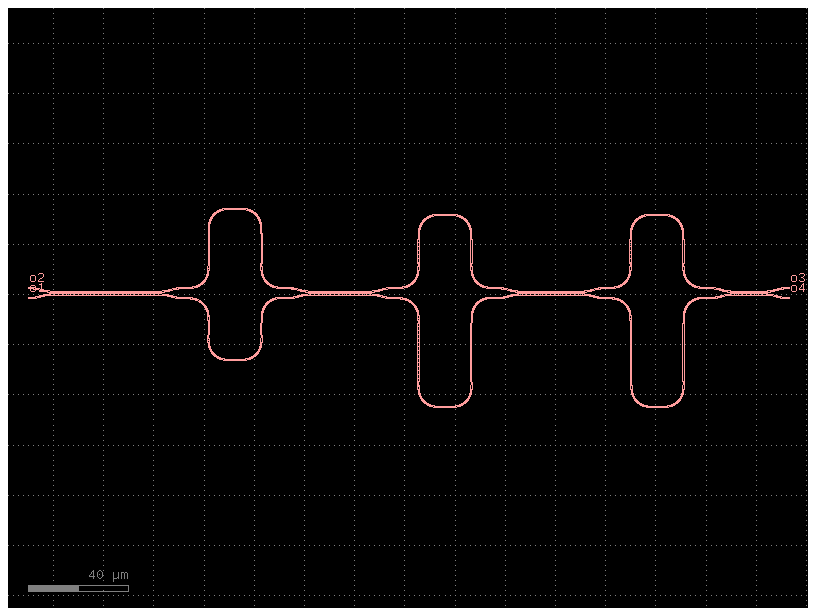

In [3]:
gf.clear_cache()

testelemento = ARTS1(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=22.63, lgthB=23.63, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = 23.250, L2 = 9.217, Lpi = 0.326
)
testelemento.draw_ports()
testelemento.plot()
testelemento.show()
testelemento.pprint_ports()

### Diseño del bloque S2

2026-05-19 16:45:16.514 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/nixtropy/pic-upv-lab5-finalproject/build/oas/1810131052.oas'


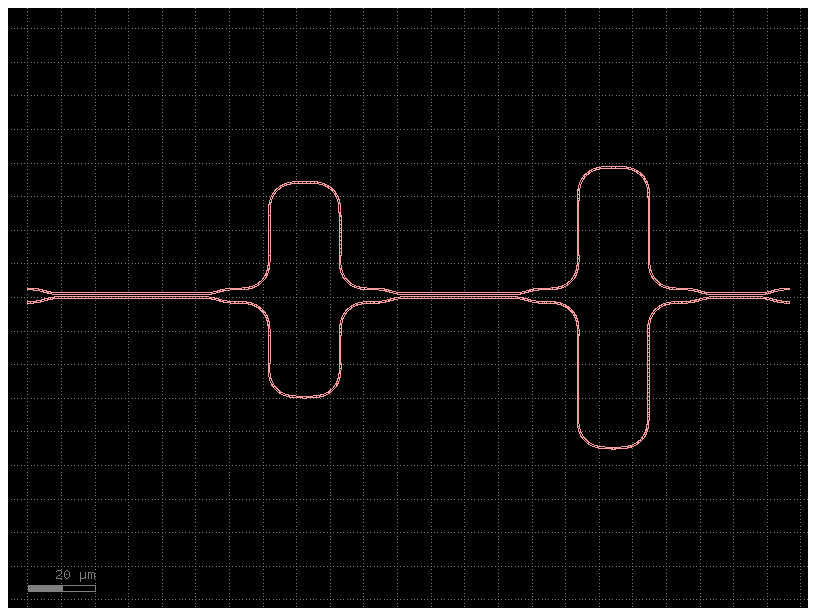

In [4]:
CMZIS2 = gf.Component()

gap=0.6 
lgthIn=41.82
lgthA=30.86
lgthOut=12.01
L1 = 23.250
L2 = 16.233
Lpi = 0.326/2

xs = gf.cross_section.strip(width=0.5, layer = 'WG')

coup = gf.components.coupler(gap=0.6, length=10, cross_section=xs)
bend = gf.components.bend_euler(cross_section=xs)
straight = gf.components.straight(length=25, cross_section=xs)

# Directional coupler
InDC = CMZIS2.add_ref(gf.components.coupler(gap=gap, length=lgthIn, cross_section=xs))
acoup = CMZIS2.add_ref(gf.components.coupler(gap=gap, length=lgthA, cross_section=xs))
OutDC = CMZIS2.add_ref(gf.components.coupler(gap=gap, length=lgthOut, cross_section=xs))
#---------------------
# MZI Aap
#---------------------
# Bends uper arm superior
ab1   = CMZIS2 << bend
ab2   = CMZIS2 << bend
ab3   = CMZIS2 << bend
ab4   = CMZIS2 << bend

# Bends lower arm inferior
ab5   = CMZIS2 << bend
ab6   = CMZIS2 << bend
ab7   = CMZIS2 << bend
ab8   = CMZIS2 << bend

# Vertical connections
asx1   = CMZIS2.add_ref(gf.components.straight(length=1, cross_section=xs))
asx2   = CMZIS2.add_ref(gf.components.straight(length=1, cross_section=xs))

# Horizontal connections
# ---- Brazo superior
asy1   = CMZIS2.add_ref(gf.components.straight(length=(L1+Lpi)/2, cross_section=xs))
asy2   = CMZIS2.add_ref(gf.components.straight(length=(L1+Lpi)/2, cross_section=xs))
# ---- Brazo inferior
asy3   = CMZIS2.add_ref(gf.components.straight(length=L2/2, cross_section=xs))
asy4   = CMZIS2.add_ref(gf.components.straight(length=L2/2, cross_section=xs))  

#---------------------
# MZI B
#---------------------
# Bends uper arm superior
bb1   = CMZIS2 << bend
bb2   = CMZIS2 << bend
bb3   = CMZIS2 << bend
bb4   = CMZIS2 << bend

# Bends lower arm inferior
bb5   = CMZIS2 << bend
bb6   = CMZIS2 << bend
bb7   = CMZIS2 << bend
bb8   = CMZIS2 << bend

# Vertical connections
bsx1   = CMZIS2.add_ref(gf.components.straight(length=1, cross_section=xs))
bsx2   = CMZIS2.add_ref(gf.components.straight(length=1, cross_section=xs))

# Horizontal connections
# ---- Brazo superior
bsy1   = CMZIS2.add_ref(gf.components.straight(length=L2, cross_section=xs))
bsy2   = CMZIS2.add_ref(gf.components.straight(length=L2, cross_section=xs))
# ---- Brazo inferior
bsy3   = CMZIS2.add_ref(gf.components.straight(length=L1+Lpi/2, cross_section=xs))
bsy4   = CMZIS2.add_ref(gf.components.straight(length=L1+Lpi/2, cross_section=xs)) 


#---------------------
# MZI A
#---------------------

ab1.connect("o1", InDC.ports["o3"])
asy1.connect("o1", ab1.ports["o2"])
ab5.connect("o1", InDC.ports["o4"], mirror=True)
asy3.connect("o1", ab5.ports["o2"])

ab2.connect("o2", asy1.ports["o2"])
ab6.connect("o1", asy3.ports["o2"])
asx1.connect("o1", ab2.ports["o1"])
asx2.connect("o1", ab6.ports["o2"])

ab3.connect("o2", asx1.ports["o2"]) 
asy2.connect("o2", ab3.ports["o1"])
ab7.connect("o1", asx2.ports["o2"]) 
asy4.connect("o1", ab7.ports["o2"])

ab4.connect("o1", asy2.ports["o1"])
ab8.connect("o2", asy4.ports["o2"])
acoup.connect("o2", ab4.ports["o2"])
acoup.connect("o1", ab8.ports["o1"])

#---------------------
# MZI B
#---------------------

bb1.connect("o1", acoup.ports["o3"])
bsy1.connect("o1", bb1.ports["o2"])
bb5.connect("o1", acoup.ports["o4"], mirror=True)
bsy3.connect("o1", bb5.ports["o2"])

bb2.connect("o2", bsy1.ports["o2"])
bb6.connect("o1", bsy3.ports["o2"])
bsx1.connect("o1", bb2.ports["o1"])
bsx2.connect("o1", bb6.ports["o2"])

bb3.connect("o2", bsx1.ports["o2"]) 
bsy2.connect("o2", bb3.ports["o1"])
bb7.connect("o1", bsx2.ports["o2"]) 
bsy4.connect("o1", bb7.ports["o2"])

bb4.connect("o1", bsy2.ports["o1"])
bb8.connect("o2", bsy4.ports["o2"])
OutDC.connect("o2", bb4.ports["o2"])
OutDC.connect("o1", bb8.ports["o1"])


CMZIS2.plot()
CMZIS2.show()



Convertir en una función de GDS Factory

In [5]:
@gf.cell
def ARTS2(gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01, L1 = 23.250, L2 = 16.233, Lpi = 0.326/2):

    CMZIS2 = gf.Component()

    xs = gf.cross_section.strip(width=0.5, layer = 'WG')

    coup = gf.components.coupler(gap=0.6, length=10, cross_section=xs)
    bend = gf.components.bend_euler(cross_section=xs)
    straight = gf.components.straight(length=25, cross_section=xs)

    # Directional coupler
    InDC = CMZIS2.add_ref(gf.components.coupler(gap=gap, length=lgthIn, cross_section=xs))
    acoup = CMZIS2.add_ref(gf.components.coupler(gap=gap, length=lgthA, cross_section=xs))
    OutDC = CMZIS2.add_ref(gf.components.coupler(gap=gap, length=lgthOut, cross_section=xs))
    #---------------------
    # MZI Aap
    #---------------------
    # Bends uper arm superior
    ab1   = CMZIS2 << bend
    ab2   = CMZIS2 << bend
    ab3   = CMZIS2 << bend
    ab4   = CMZIS2 << bend

    # Bends lower arm inferior
    ab5   = CMZIS2 << bend
    ab6   = CMZIS2 << bend
    ab7   = CMZIS2 << bend
    ab8   = CMZIS2 << bend

    # Vertical connections
    asx1   = CMZIS2.add_ref(gf.components.straight(length=1, cross_section=xs))
    asx2   = CMZIS2.add_ref(gf.components.straight(length=1, cross_section=xs))

    # Horizontal connections
    # ---- Brazo superior
    asy1   = CMZIS2.add_ref(gf.components.straight(length=(L1+Lpi)/2, cross_section=xs))
    asy2   = CMZIS2.add_ref(gf.components.straight(length=(L1+Lpi)/2, cross_section=xs))
    # ---- Brazo inferior
    asy3   = CMZIS2.add_ref(gf.components.straight(length=L2/2, cross_section=xs))
    asy4   = CMZIS2.add_ref(gf.components.straight(length=L2/2, cross_section=xs))  

    #---------------------
    # MZI B
    #---------------------
    # Bends uper arm superior
    bb1   = CMZIS2 << bend
    bb2   = CMZIS2 << bend
    bb3   = CMZIS2 << bend
    bb4   = CMZIS2 << bend

    # Bends lower arm inferior
    bb5   = CMZIS2 << bend
    bb6   = CMZIS2 << bend
    bb7   = CMZIS2 << bend
    bb8   = CMZIS2 << bend

    # Vertical connections
    bsx1   = CMZIS2.add_ref(gf.components.straight(length=1, cross_section=xs))
    bsx2   = CMZIS2.add_ref(gf.components.straight(length=1, cross_section=xs))

    # Horizontal connections
    # ---- Brazo superior
    bsy1   = CMZIS2.add_ref(gf.components.straight(length=L2, cross_section=xs))
    bsy2   = CMZIS2.add_ref(gf.components.straight(length=L2, cross_section=xs))
    # ---- Brazo inferior
    bsy3   = CMZIS2.add_ref(gf.components.straight(length=L1+Lpi/2, cross_section=xs))
    bsy4   = CMZIS2.add_ref(gf.components.straight(length=L1+Lpi/2, cross_section=xs)) 


    #---------------------
    # MZI A
    #---------------------

    ab1.connect("o1", InDC.ports["o3"])
    asy1.connect("o1", ab1.ports["o2"])
    ab5.connect("o1", InDC.ports["o4"], mirror=True)
    asy3.connect("o1", ab5.ports["o2"])

    ab2.connect("o2", asy1.ports["o2"])
    ab6.connect("o1", asy3.ports["o2"])
    asx1.connect("o1", ab2.ports["o1"])
    asx2.connect("o1", ab6.ports["o2"])

    ab3.connect("o2", asx1.ports["o2"]) 
    asy2.connect("o2", ab3.ports["o1"])
    ab7.connect("o1", asx2.ports["o2"]) 
    asy4.connect("o1", ab7.ports["o2"])

    ab4.connect("o1", asy2.ports["o1"])
    ab8.connect("o2", asy4.ports["o2"])
    acoup.connect("o2", ab4.ports["o2"])
    acoup.connect("o1", ab8.ports["o1"])

    #---------------------
    # MZI B
    #---------------------

    bb1.connect("o1", acoup.ports["o3"])
    bsy1.connect("o1", bb1.ports["o2"])
    bb5.connect("o1", acoup.ports["o4"], mirror=True)
    bsy3.connect("o1", bb5.ports["o2"])

    bb2.connect("o2", bsy1.ports["o2"])
    bb6.connect("o1", bsy3.ports["o2"])
    bsx1.connect("o1", bb2.ports["o1"])
    bsx2.connect("o1", bb6.ports["o2"])

    bb3.connect("o2", bsx1.ports["o2"]) 
    bsy2.connect("o2", bb3.ports["o1"])
    bb7.connect("o1", bsx2.ports["o2"]) 
    bsy4.connect("o1", bb7.ports["o2"])

    bb4.connect("o1", bsy2.ports["o1"])
    bb8.connect("o2", bsy4.ports["o2"])
    OutDC.connect("o2", bb4.ports["o2"])
    OutDC.connect("o1", bb8.ports["o1"])

    #---------------------
    # Puertos
    #---------------------

    CMZIS2.add_port("o1", port=InDC.ports["o1"])
    CMZIS2.add_port("o2", port=InDC.ports["o2"])
    CMZIS2.add_port("o3", port=OutDC.ports["o3"])
    CMZIS2.add_port("o4", port=OutDC.ports["o4"])

    return CMZIS2



2026-05-19 16:45:24.922 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/nixtropy/pic-upv-lab5-finalproject/build/oas/2489567549.oas'


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center                       ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 0.5   │ 180.0       │ WG (1/0) │ (-10.0, -1.45)               │ optical   │
│ o2   │ 0.5   │ 180.0       │ WG (1/0) │ (-10.0, 2.5500000000000003)  │ optical   │
│ o3   │ 0.5   │ 0.0         │ WG (1/0) │ (216.69, 2.5500000000000003) │ optical   │
│ o4   │ 0.5   │ 0.0         │ WG (1/0) │ (216.69, -1.45)              │ optical   │
└──────┴───────┴─────────────┴──────────┴──────────────────────────────┴───────────┘

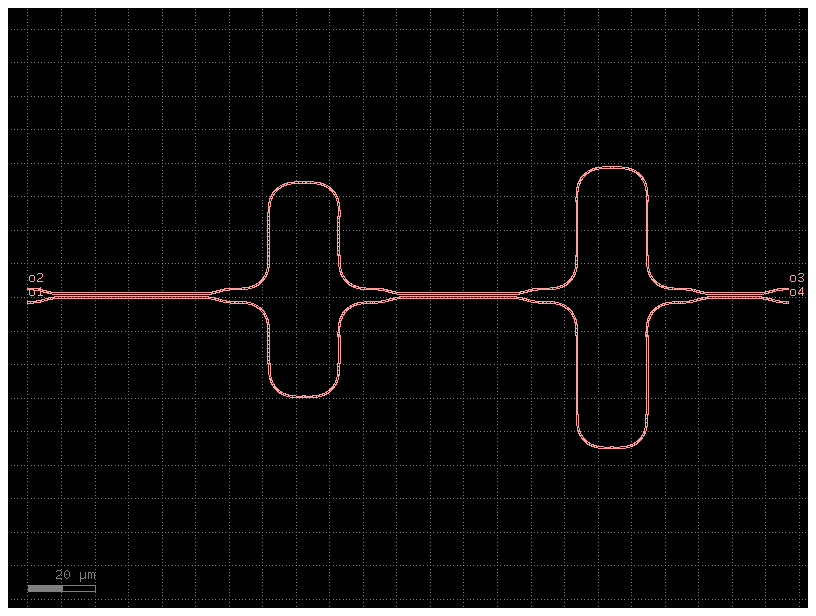

In [6]:
gf.clear_cache()

testelemento = ARTS2(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = 23.250, L2 = 16.233, Lpi = 0.326/2
)
testelemento.draw_ports()
testelemento.plot()
testelemento.show()
testelemento.pprint_ports()

2026-05-19 16:45:27.199 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/nixtropy/pic-upv-lab5-finalproject/build/oas/1593756270.oas'


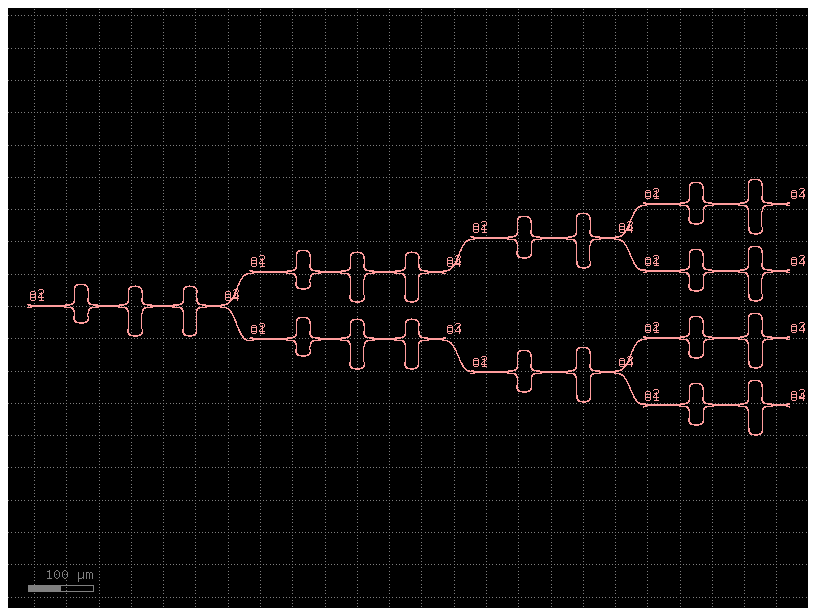

In [7]:
gf.clear_cache()

WDM = gf.Component()

Lpi = 0.326  # um
L1 = 23.250  # um
L2_S1 = 9.217  # um
L2_S2 = 16.233  # um
Lpi_05 = 0.5 * Lpi # um

x_sep = 50
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

S1 = ARTS1(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=22.63, lgthB=23.63, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = L1, L2 = L2_S1, Lpi = Lpi
)

S2 = ARTS2(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = L1, L2 = L2_S2, Lpi = 0
)

S2_mod = ARTS2(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = L1, L2 = L2_S2, Lpi = Lpi_05
)

#--------------------------------------------
# MZI necesarios para el WDM
#--------------------------------------------

AS1In = WDM << S1
# Stage 2
BS1Top = WDM << S1
BS1Btm = WDM << S1
# Stage 3
CS2Top = WDM << S2
CS2Btm = WDM << S2_mod
# Stage 4
DS2Out1 = WDM << S2
DS2Out2 = WDM << S2
DS2Out3 = WDM << S2_mod
DS2Out4 = WDM << S2_mod

#--------------------------------------------
# Mover los MZI para facilitar su conexión
#--------------------------------------------

# MZI Segunda etapa
BS1Top.dmovey(AS1In.ports["o3"].dy+50).dmovex(AS1In.ports["o3"].dx+x_sep)
BS1Btm.dmovey(AS1In.ports["o4"].dy-50).dmovex(AS1In.ports["o4"].dx+x_sep)

# MZI tercera etapa

CS2Top.dmovey(BS1Top.ports["o3"].dy+50).dmovex(BS1Top.ports["o3"].dx+x_sep)
CS2Btm.dmovey(BS1Btm.ports["o4"].dy-50).dmovex(BS1Btm.ports["o4"].dx+x_sep)

# MZI cuarta etapa

DS2Out1.dmovey(CS2Top.ports["o3"].dy+50).dmovex(CS2Top.ports["o3"].dx+x_sep)
DS2Out2.dmovey(CS2Top.ports["o4"].dy-50).dmovex(CS2Top.ports["o4"].dx+x_sep)

DS2Out3.dmovey(CS2Btm.ports["o3"].dy+50).dmovex(CS2Btm.ports["o3"].dx+x_sep)
DS2Out4.dmovey(CS2Btm.ports["o4"].dy-50).dmovex(CS2Btm.ports["o4"].dx+x_sep)

# #--------------------------------------------
# # Mover los MZI para facilitar su conexión
# #--------------------------------------------

# Etapa 1 a etapa 2
gf.routing.route_single_sbend(WDM,port1=AS1In['o3'], port2=BS1Top['o1'], cross_section=xs)
gf.routing.route_single_sbend(WDM,port1=AS1In['o4'], port2=BS1Btm['o1'], cross_section=xs)

# Etapa 2 a etapa 3

gf.routing.route_single_sbend(WDM,port1=BS1Top['o3'], port2=CS2Top['o1'], cross_section=xs)
gf.routing.route_single_sbend(WDM,port1=BS1Btm['o4'], port2=CS2Btm['o2'], cross_section=xs)

# Etapa 3 a etapa 4

gf.routing.route_single_sbend(WDM,port1=CS2Top['o3'], port2=DS2Out1['o1'], cross_section=xs)
gf.routing.route_single_sbend(WDM,port1=CS2Top['o4'], port2=DS2Out2['o2'], cross_section=xs)
gf.routing.route_single_sbend(WDM,port1=CS2Btm['o3'], port2=DS2Out3['o1'], cross_section=xs)
gf.routing.route_single_sbend(WDM,port1=CS2Btm['o4'], port2=DS2Out4['o2'], cross_section=xs)

WDM.add_ports(AS1In.ports)
WDM.add_ports(BS1Top.ports)
WDM.add_ports(BS1Btm.ports)
WDM.add_ports(CS2Top.ports)
WDM.add_ports(CS2Btm.ports)
WDM.add_ports(DS2Out1.ports)
WDM.add_ports(DS2Out2.ports)
WDM.add_ports(DS2Out3.ports)
WDM.add_ports(DS2Out4.ports)
WDM.draw_ports()
WDM.plot()
WDM.show()

In [8]:
@gf.cell
def WDM():

    _WDM = gf.Component()

    Lpi = 0.326  # um
    L1 = 23.250  # um
    L2_S1 = 9.217  # um
    L2_S2 = 16.233  # um
    Lpi_05 = 0.5 * Lpi # um

    x_sep = 50
    xs = gf.cross_section.strip(width=0.5, layer = 'WG')

    S1 = ARTS1(
        # Informacion coupler
        gap=0.6, lgthIn=41.82, lgthA=22.63, lgthB=23.63, lgthOut=12.01,
        # Informacion brazos MZI
        L1 = L1, L2 = L2_S1, Lpi = Lpi
    )

    S2 = ARTS2(
        # Informacion coupler
        gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01,
        # Informacion brazos MZI
        L1 = L1, L2 = L2_S2, Lpi = 0
    )

    S2_mod = ARTS2(
        # Informacion coupler
        gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01,
        # Informacion brazos MZI
        L1 = L1, L2 = L2_S2, Lpi = Lpi_05
    )

    #--------------------------------------------
    # MZI necesarios para el _WDM
    #--------------------------------------------

    AS1In = _WDM << S1
    # Stage 2
    BS1Top = _WDM << S1
    BS1Btm = _WDM << S1
    # Stage 3
    CS2Top = _WDM << S2
    CS2Btm = _WDM << S2_mod
    # Stage 4
    DS2Out1 = _WDM << S2
    DS2Out2 = _WDM << S2
    DS2Out3 = _WDM << S2_mod
    DS2Out4 = _WDM << S2_mod

    #--------------------------------------------
    # Mover los MZI para facilitar su conexión
    #--------------------------------------------

    # MZI Segunda etapa
    BS1Top.dmovey(AS1In.ports["o3"].dy+50).dmovex(AS1In.ports["o3"].dx+x_sep)
    BS1Btm.dmovey(AS1In.ports["o4"].dy-50).dmovex(AS1In.ports["o4"].dx+x_sep)

    # MZI tercera etapa

    CS2Top.dmovey(BS1Top.ports["o3"].dy+50).dmovex(BS1Top.ports["o3"].dx+x_sep)
    CS2Btm.dmovey(BS1Btm.ports["o4"].dy-50).dmovex(BS1Btm.ports["o4"].dx+x_sep)

    # MZI cuarta etapa

    DS2Out1.dmovey(CS2Top.ports["o3"].dy+50).dmovex(CS2Top.ports["o3"].dx+x_sep)
    DS2Out2.dmovey(CS2Top.ports["o4"].dy-50).dmovex(CS2Top.ports["o4"].dx+x_sep)

    DS2Out3.dmovey(CS2Btm.ports["o3"].dy+50).dmovex(CS2Btm.ports["o3"].dx+x_sep)
    DS2Out4.dmovey(CS2Btm.ports["o4"].dy-50).dmovex(CS2Btm.ports["o4"].dx+x_sep)

    # #--------------------------------------------
    # # Mover los MZI para facilitar su conexión
    # #--------------------------------------------

    # Etapa 1 a etapa 2
    gf.routing.route_single_sbend(_WDM,port1=AS1In['o3'], port2=BS1Top['o1'], cross_section=xs)
    gf.routing.route_single_sbend(_WDM,port1=AS1In['o4'], port2=BS1Btm['o1'], cross_section=xs)

    # Etapa 2 a etapa 3

    gf.routing.route_single_sbend(_WDM,port1=BS1Top['o3'], port2=CS2Top['o1'], cross_section=xs)
    gf.routing.route_single_sbend(_WDM,port1=BS1Btm['o4'], port2=CS2Btm['o2'], cross_section=xs)

    # Etapa 3 a etapa 4

    gf.routing.route_single_sbend(_WDM,port1=CS2Top['o3'], port2=DS2Out1['o1'], cross_section=xs)
    gf.routing.route_single_sbend(_WDM,port1=CS2Top['o4'], port2=DS2Out2['o2'], cross_section=xs)
    gf.routing.route_single_sbend(_WDM,port1=CS2Btm['o3'], port2=DS2Out3['o1'], cross_section=xs)
    gf.routing.route_single_sbend(_WDM,port1=CS2Btm['o4'], port2=DS2Out4['o2'], cross_section=xs)

        # Definir puertos

    _WDM.add_port("o1", port=AS1In.ports["o1"])
    _WDM.add_port("o2", port=AS1In.ports["o2"])
    _WDM.add_port("o3", port=DS2Out1.ports["o3"])
    _WDM.add_port("o4", port=DS2Out2.ports["o3"])
    _WDM.add_port("o5", port=DS2Out3.ports["o4"])
    _WDM.add_port("o6", port=DS2Out4.ports["o4"])

    return _WDM



2026-05-19 16:45:35.072 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/nixtropy/pic-upv-lab5-finalproject/build/oas/1037882451.oas'


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center                         ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 0.5   │ 180.0       │ WG (1/0) │ (-10.0, -1.45)                 │ optical   │
│ o2   │ 0.5   │ 180.0       │ WG (1/0) │ (-10.0, 2.5500000000000003)    │ optical   │
│ o3   │ 0.5   │ 0.0         │ WG (1/0) │ (1169.56, 160.20000000000002)  │ optical   │
│ o4   │ 0.5   │ 0.0         │ WG (1/0) │ (1169.56, 56.2)                │ optical   │
│ o5   │ 0.5   │ 0.0         │ WG (1/0) │ (1169.56, -51.800000000000004) │ optical   │
│ o6   │ 0.5   │ 0.0         │ WG (1/0) │ (1169.56, -155.8)              │ optical   │
└──────┴───────┴─────────────┴──────────┴────────────────────────────────┴───────────┘

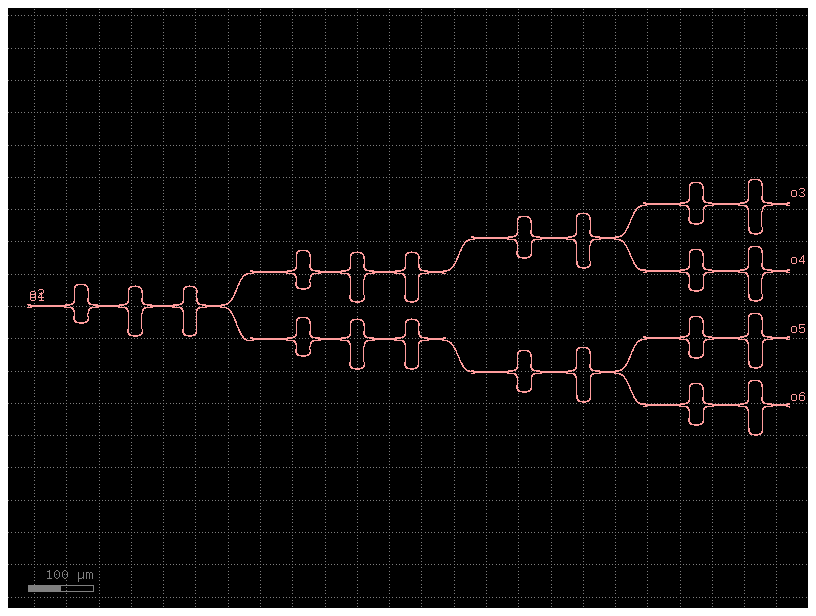

In [9]:
gf.clear_cache()

testelemento = WDM()
testelemento.draw_ports()
testelemento.plot()
testelemento.show()
testelemento.pprint_ports()

In [10]:
@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box


Deseamos generar un patron que sea repetible por medio de inteligencia artificial, asi que hacemos una estructura de prueba.

2026-05-19 16:45:39.656 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/nixtropy/pic-upv-lab5-finalproject/build/oas/1873567382.oas'


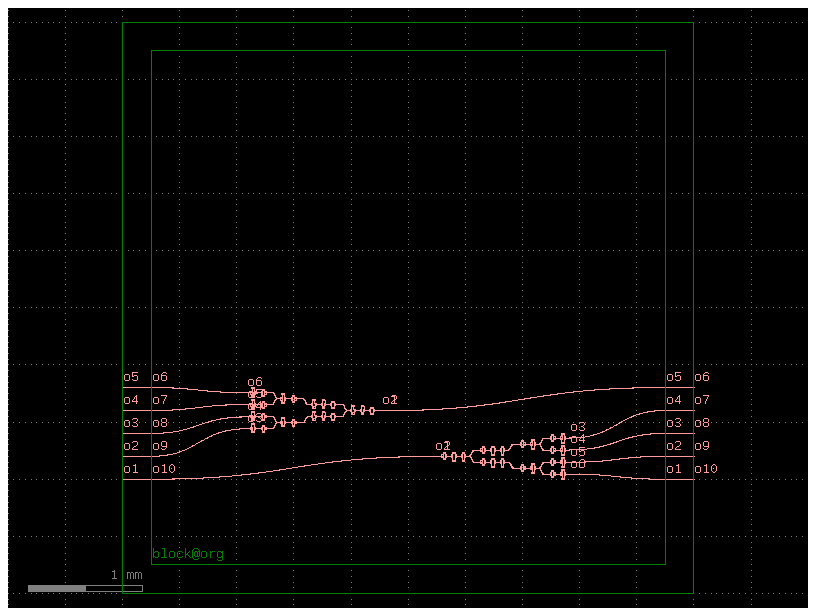

In [11]:
main = gf.Component()

sp = 200
border = 250
dieW = 5000
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

dielab = die(layer_box="FLOORPLAN")
WDM_F = WDM()

in_arr = main.add_ref(
    gf.components.straight_array(n=5, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=5, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)


_dielab = main << dielab
_WDM_1 = main << WDM_F
_WDM_2 = main << WDM_F


# Mover el WDM al centro del die
_WDM_1.dmovex(2*dieW/3 - WDM_F.dxsize/2).dmovey(in_arr['o9'].dy)
_WDM_2.rotate(180).dmovex(dieW/3 + WDM_F.dxsize/2).dmovey(out_arr['o4'].dy)

# Conexiones
gf.routing.route_single_sbend(main, port1=_WDM_1['o6'], port2=out_arr['o1'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_WDM_1['o5'], port2=out_arr['o2'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_WDM_1['o4'], port2=out_arr['o3'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_WDM_1['o3'], port2=out_arr['o4'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_WDM_1['o1'], port2=in_arr['o10'], cross_section=xs) 

gf.routing.route_single_sbend(main, port1=_WDM_2['o6'], port2=in_arr['o6'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_WDM_2['o5'], port2=in_arr['o7'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_WDM_2['o4'], port2=in_arr['o8'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_WDM_2['o3'], port2=in_arr['o9'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_WDM_2['o2'], port2=out_arr['o5'], cross_section=xs)

main.add_ports(in_arr.ports)
main.add_ports(out_arr.ports)
main.draw_ports()
main.plot()
main.show()

Este es el resultado entregado por la IA, solo es necesario establecer el numero de bloques que se desean para repetir el patron

2026-05-19 17:53:45.672 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/nixtropy/pic-upv-lab5-finalproject/build/oas/1716840458.oas'


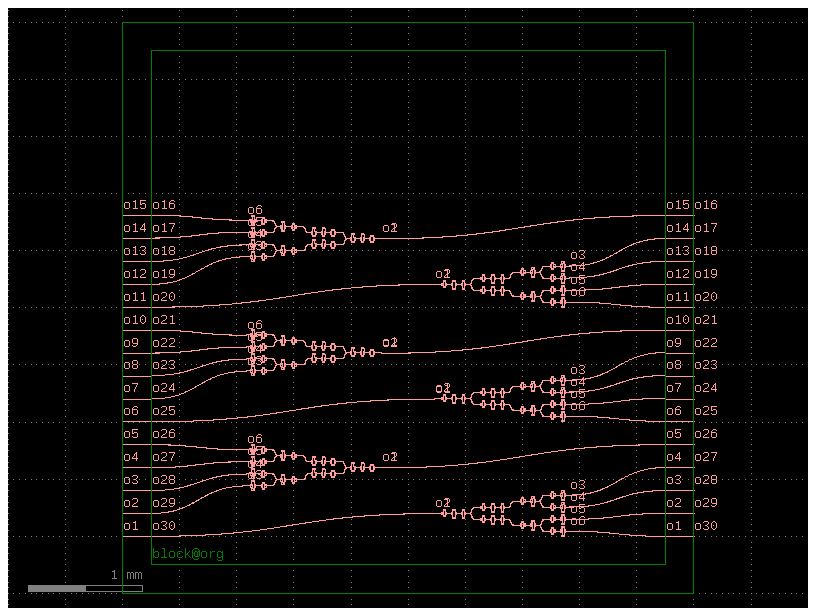

In [34]:
# Layout repetible: cambia este numero para agregar mas bloques de WDM
num_wdm_blocks = 3

main = gf.Component()

sp = 200
border = 250
dieW = 5000
routes_per_block = 5
n_routes = routes_per_block * num_wdm_blocks
xs = gf.cross_section.strip(width=0.5, layer='WG')

dielab = die(layer_box="FLOORPLAN")
WDM_F = WDM()

in_arr = main.add_ref(
    gf.components.straight_array(n=n_routes, spacing=sp, length=border, cross_section=xs)
).dmovey(
    500
)

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=n_routes, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(500)
)

_dielab = main << dielab
wdm_refs = []

for block in range(num_wdm_blocks):
    lane0 = routes_per_block * block

    # Puertos del grupo actual, ordenados de abajo a arriba.
    out_ports = [out_arr[f"o{lane0 + i + 1}"] for i in range(routes_per_block)]
    in_ports = [in_arr[f"o{2 * n_routes - (lane0 + i)}"] for i in range(routes_per_block)]

    wdm_right = main << WDM_F
    wdm_left = main << WDM_F
    wdm_refs.append((wdm_left, wdm_right))

    # Colocar los dos WDM del bloque sin escribirlos uno a uno.
    wdm_right.dmovex(2 * dieW / 3 - WDM_F.dxsize / 2).dmovey(in_ports[1].dy)
    wdm_left.rotate(180).dmovex(dieW / 3 + WDM_F.dxsize / 2).dmovey(out_ports[3].dy)

    # Conexiones hacia el array de salida.
    for wdm_port, out_port in zip(("o6", "o5", "o4", "o3"), out_ports[:4]):
        gf.routing.route_single_sbend(main, port1=wdm_right[wdm_port], port2=out_port, cross_section=xs)
    gf.routing.route_single_sbend(main, port1=wdm_right["o1"], port2=in_ports[0], cross_section=xs)

    # Conexiones hacia el array de entrada.
    for wdm_port, in_port in zip(("o6", "o5", "o4", "o3"), reversed(in_ports[1:])):
        gf.routing.route_single_sbend(main, port1=wdm_left[wdm_port], port2=in_port, cross_section=xs)
    gf.routing.route_single_sbend(main, port1=wdm_left["o2"], port2=out_ports[4], cross_section=xs)

main.add_ports(in_arr.ports)
main.add_ports(out_arr.ports)
main.draw_ports()
main.plot()
main.show()

In [95]:
print(_WDM_1['o6'].width)
print(out_arr['o1'].width)

0.5
0.5


2026-05-19 18:02:46.580 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/nixtropy/pic-upv-lab5-finalproject/build/oas/857112535.oas'


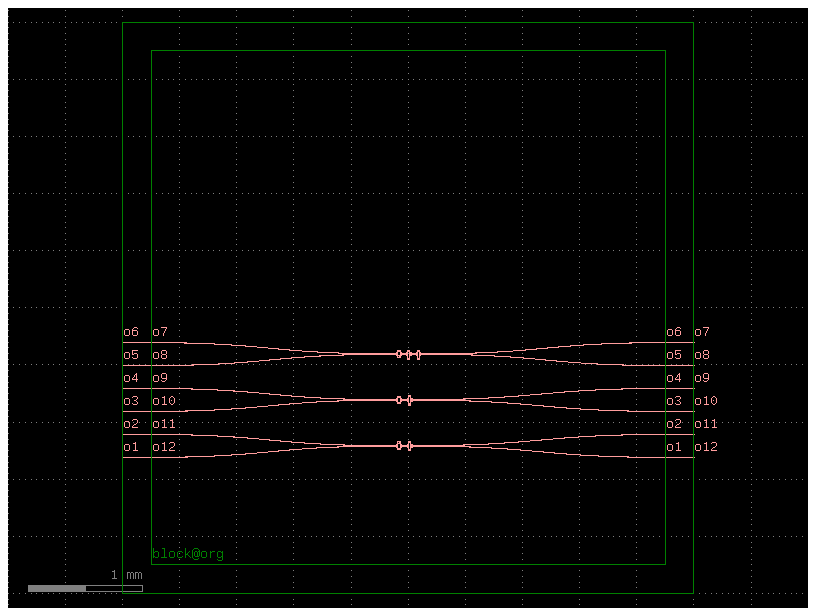

In [35]:
main = gf.Component()

sp = 200
border = 250
dieW = 5000
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

dielab = die(layer_box="FLOORPLAN")
WDM_F = WDM()

Lpi = 0.326  # um
L1 = 23.250  # um
L2_S1 = 9.217  # um
L2_S2 = 16.233  # um
Lpi_05 = 0.5 * Lpi # um

S1 = ARTS1(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=22.63, lgthB=23.63, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = L1, L2 = L2_S1, Lpi = Lpi
)

S2 = ARTS2(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = L1, L2 = L2_S2, Lpi = 0
)

S2_mod = ARTS2(
    # Informacion coupler
    gap=0.6, lgthIn=41.82, lgthA=30.86, lgthOut=12.01,
    # Informacion brazos MZI
    L1 = L1, L2 = L2_S2, Lpi = Lpi_05
)



in_arr = main.add_ref(
    gf.components.straight_array(n=6, spacing=sp, length=border, cross_section=xs)
).dmovey(
    dieW - in_arr.dysize - 1000
)  

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=6, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(dieW - out_arr.dysize - 1000)
)


_dielab = main << dielab
_S1 = main << S1
_S2 = main << S2
_S2_mod = main << S2_mod


# Mover el WDM al centro del die
_S1.dmovex(dieW/2 - _S1.dxsize/2).dmovey(in_arr['o8'].dy + sp/2)
_S2.dmovex(dieW/2 - _S1.dxsize/2).dmovey(in_arr['o10'].dy + sp/2)
_S2_mod.dmovex(dieW/2 - _S1.dxsize/2).dmovey(in_arr['o12'].dy + sp/2)

# Conexiones
gf.routing.route_single_sbend(main, port1=_S1['o2'], port2=in_arr['o7'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S1['o1'], port2=in_arr['o8'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S1['o3'], port2=out_arr['o6'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S1['o4'], port2=out_arr['o5'], cross_section=xs)

gf.routing.route_single_sbend(main, port1=_S2['o2'], port2=in_arr['o9'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2['o1'], port2=in_arr['o10'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2['o3'], port2=out_arr['o4'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2['o4'], port2=out_arr['o3'], cross_section=xs)

gf.routing.route_single_sbend(main, port1=_S2_mod['o2'], port2=in_arr['o11'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_mod['o1'], port2=in_arr['o12'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_mod['o3'], port2=out_arr['o2'], cross_section=xs)
gf.routing.route_single_sbend(main, port1=_S2_mod['o4'], port2=out_arr['o1'], cross_section=xs)


main.add_ports(in_arr.ports)
main.add_ports(out_arr.ports)
main.draw_ports()
main.plot()
main.show()